# FATINT experiments

All experiments below repeat each run ten times with seeds $1..10$ using a C++ implementation of FATINT.

Species counting uses a disjoint-set structure to count connected components, where a connection exists for each pair of entities with a eucledian distance in phenotype space less than $M_{limit}$, which is a condition of reproductive compatibility.

In [1]:
# Run the C++ implementation of FATINT
from subprocess import run

# Progress bar
from tqdm.notebook import tqdm

# Capture simulation results and pass to Polars
from os.path import isfile
from io import BytesIO

# Parse the generated CSV
import polars as pl

# Plot the results
import matplotlib.pyplot as plt

In [2]:
def sweep(option, vrange, args=[]):
    '''
    Iterates through the given values for the given option
    and runs a simulation for each.
    '''
    results = []
    for v in tqdm(vrange):
        fname = 'outputs/' + option + '=' + str(v) + ''.join(args) + '.csv'
        if not isfile(fname):
            with open(fname, 'w') as of:
                result = run(
                    ['../build/fatint', '--' + option + '=' + str(v)] + args, 
                    stdout=of)
        results.append(pl.read_csv(fname))
    return results

In [3]:
def plot(results, option, vrange, y_lim=30, s=2):
    '''
    Produces a scatter plot of the average species counts
    with grey bars showing the minimum and maximum value.
    '''
    fig, ax = plt.subplots()

    for result in results:
        ax.fill_between(
            result['Step'],
            result['SpeciesMin'],
            result['SpeciesMax'],
            color='0.9',
            label='_nolegend_')

    legend = []
    markers = 'osDx+v^*osDx+v^*osDx+v^*osDx+v^*'
    for result, value, marker in zip(results, vrange, markers):
        legend.append('Average species count, ' + option + '=' + str(value))
        ax.scatter(
            result['Step'],
            result['SpeciesAvg'],
            s=s,
            marker=marker)

    ax.legend(legend, loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_ylim([0, y_lim])
    fig.set_size_inches(10, 5)
    return fig, ax

## Sweeping $P_{encounter}$

In [4]:
sweep_encounter = sweep('p_encounter', [v / 1000.0 for v in range(50, 100, 5)])

  0%|          | 0/10 [00:00<?, ?it/s]

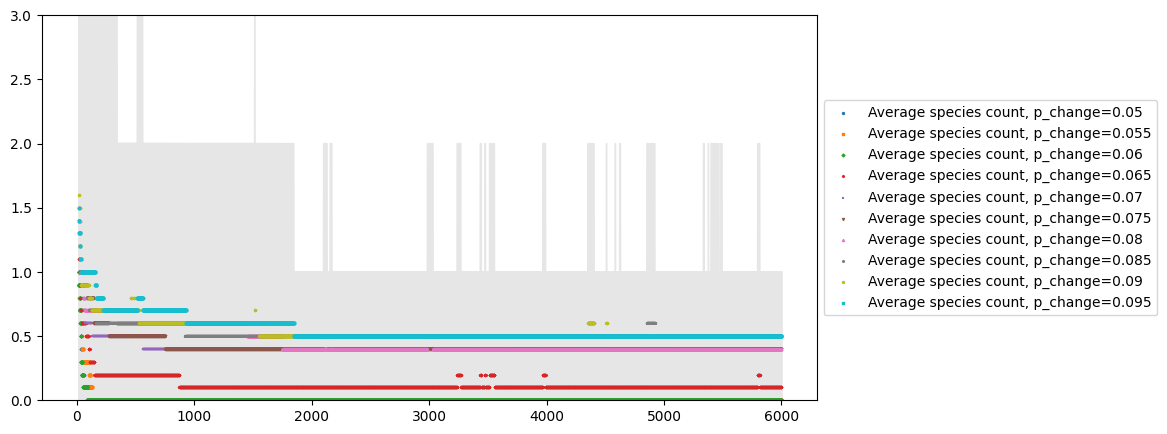

In [5]:
_ = plot(sweep_encounter, 'p_change', [v / 1000.0 for v in range(50, 100, 5)], y_lim=3)

## Sweeping $P_{mutation}$

In [6]:
sweep_mutation = sweep('p_mutation', [v / 10.0 for v in range(0, 6)])

  0%|          | 0/6 [00:00<?, ?it/s]

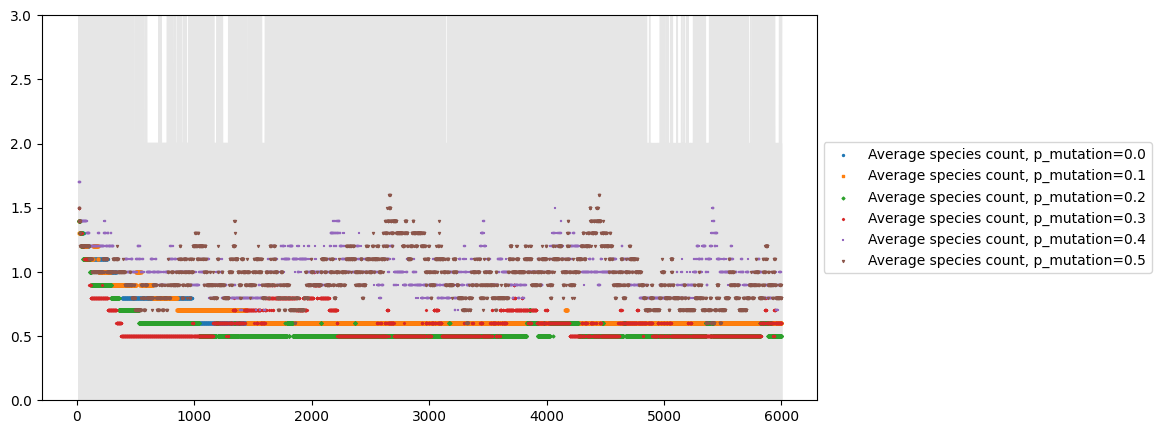

In [7]:
_ = plot(sweep_mutation, 'p_mutation', [v / 10.0 for v in range(0,6)], y_lim=3)

## Sweeping $P_{crossing}$

In [8]:
sweep_crossing = sweep('p_crossing', [v / 10.0 for v in range(0, 9)])

  0%|          | 0/9 [00:00<?, ?it/s]

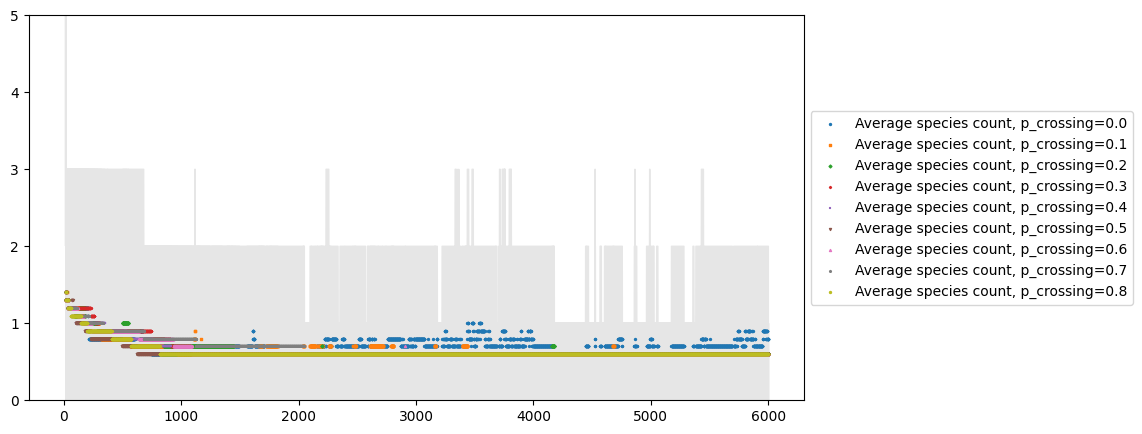

In [9]:
_ = plot(sweep_crossing, 'p_crossing', [v / 10.0 for v in range(0, 9)], y_lim=5)

## Sweeping $P_{change}$

In [10]:
sweep_change = sweep('p_change', [v / 100000.0 for v in range(50, 100, 5)])

  0%|          | 0/10 [00:00<?, ?it/s]

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

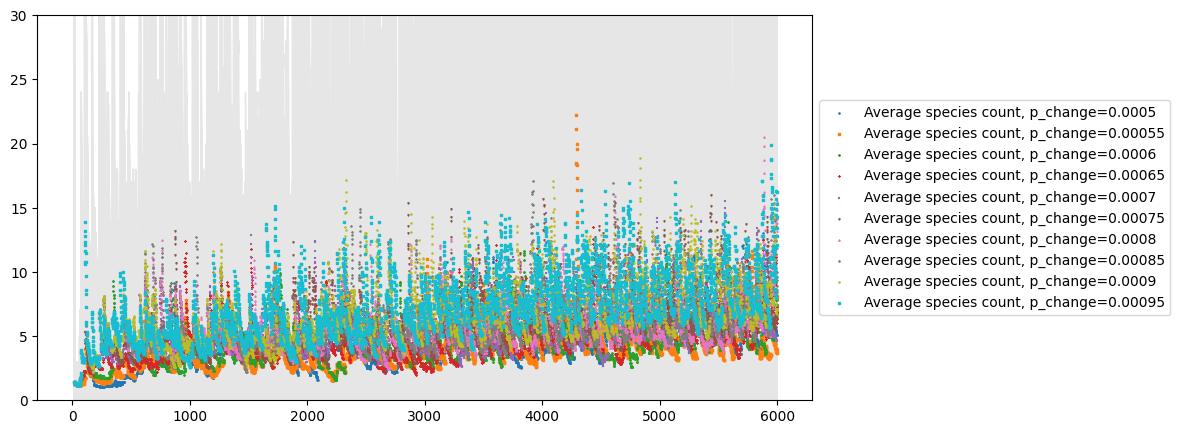

In [11]:
plot(sweep_change, 'p_change', [v / 100000.0 for v in range(50, 100, 5)], y_lim=30, s=0.75)

## Sweeping $M_{limit}$, $P_{change}=0.0005$

In [ ]:
sweep_limit = sweep('m_limit', range(0, 21), args=['--p_change=0.0005'])

  0%|          | 0/21 [00:00<?, ?it/s]

In [ ]:
_ = plot(sweep_limit, 'm_limit', range(0, 21), y_lim=20, s=0.75)

## Sweeping $V_{stretch}$, $P_{change}=0.0005$

In [ ]:
sweep_stretch = sweep('v_stretch', range(1, 21), args=['--p_change=0.0005'])

In [ ]:
_ = plot(sweep_stretch, 'v_stretch', range(1, 21), y_lim=20, s=0.75)